In [1]:
import ast
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import seaborn as sns
import numpy as np
from matplotlib.gridspec import GridSpec
from matplotlib import gridspec
from matplotlib.ticker import MaxNLocator, FuncFormatter
from matplotlib import cm
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import xarray as xr
from shapely.geometry import mapping, shape, MultiPolygon, box, Point
from affine import Affine
import rasterio
from shapely import wkt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import os
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import numpy as np
import logging
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import matplotlib.patches as mpatches  # Import for custom legend
from dotenv import load_dotenv
import os
from pathlib import Path
import json
from tqdm import tqdm  # Import tqdm for the progress bar
import numpy as np
from shapely.geometry import Polygon
from matplotlib.colors import LinearSegmentedColormap
import rioxarray
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import pandas as pd
from scipy.stats import zscore
from scipy.stats import zscore
from scipy.signal import savgol_filter, find_peaks
from scipy.ndimage import gaussian_filter
from rioxarray.exceptions import NoDataInBounds  # Import NoDataInBounds exception
from pathlib import Path
import os
import itertools
import logging
import xarray as xr
import pandas as pd
import geopandas as gpd
from shapely.geometry import mapping
import geopandas as gpd
import pandas as pd
from shapely.ops import unary_union

# Set font sizes for various components
plt.rcParams.update({
    'font.size': 16,           # Global font size
    'axes.titlesize': 24,      # Title font size
    'axes.labelsize': 24,      # X and Y label font size
    'xtick.labelsize': 16,     # X tick label font size
    'ytick.labelsize': 16,     # Y tick label font size
})

# Importing specific functions from the module
from func_preprocessing import restructure_dataset, remove_outliers, smooth
from func_indecies import ndvi, nbr, ndwi, ndre, tcw, tcg, tcb, ndmi, nirv, kndvi, drs, ndrs, kdrs, kndrs
from func_helper import parse_custom_colors, format_label
from func_file_io import load_data

In [6]:
# Load environment variables from the .env file
env_path = Path('/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/environment/.env')
#env_path = Path('/work/sy58xupo-cleaning/sy58xupo-CleaningSpace-1736389214/ForExD-WP1-P1/environment/.env')
load_dotenv(dotenv_path=env_path)

# Retrieve and parse custom color settings from environment variables
custom_colors_json = os.getenv('COLORS')
custom_colors = parse_custom_colors(custom_colors_json)

# Retrieve environment variables
grid_folder = os.getenv('EQUI7_GRIDS_DIR')
print(f"Equi7 grids folder: {grid_folder}")

# Check if the folder exists
if not os.path.isdir(grid_folder):
    raise FileNotFoundError(f"The folder {grid_folder} does not exist.")

# Retrieve the CRS (Coordinate Reference System) for Equi7 NA
equi7_crs = os.getenv('EQUI7_NA_EPSG')

# Ensure the 'REGION' environment variable is set
region = os.getenv('REGION')
if region is None:
    raise ValueError("The 'REGION' environment variable is not set. Please ensure it is defined in the .env file.")

# Format region ID as a two-digit string
region_id = str(region).zfill(2)

# Parameters for the grid
resolution = 10
pixel_size = 512

netcdf_data_path = os.getenv('WP1_DATA')
print(f"Netcdf Data folder: {netcdf_data_path}")
s1dm_s1_figure_path = os.getenv('WP1_FIGURE')
print(f"Netcdf Figures folder: {s1dm_s1_figure_path}")

figures_path = os.getenv('FIGURES')
print(f"Figures folder: {figures_path}")

ids_path = f"{os.getenv('RESULTS_DIR')}/region_{region_id}_dca_filtered_ids_usda_polygons.shp"
refdm_path = f"{os.getenv('RESULTS_DIR')}/radar_enhanced_forest_disturbance_mapping_region_{region_id}_buffer_500_s1dm.shp"
path_grid = f"{grid_folder}/grid_equi7_{resolution}_{pixel_size}_region_{region_id}.shp"
path_conves = f"{os.getenv('RESULTS_DIR')}/radar_results/convex_hulls_refdm_region_{region_id}_epsg_4326.shp"
#path_intersetion_grid = f"{grid_folder}/intersected_grid_{resolution}_{pixel_size}_region_{region_id}.shp"
path_intersetion_grid = f"{grid_folder}/grid_equi7_10_512_region_08_intersetion.shp"


tcc_file = f"{os.getenv('TCC_PATH')}/wp1_nlcd_tcc_conus_2017_v2021_4_20m_EPSG_27705_cropped_region_08.tif"
figure_output_path = f"{os.getenv('FIGURES')}"
if not os.path.exists(figure_output_path):
        os.makedirs(figure_output_path)

data_output_path = f"{os.getenv('DATA_INTERMEDIATE')}"
if not os.path.exists(data_output_path):
        os.makedirs(data_output_path)
        
        

s2_minicube_folder = os.getenv('SENTINEL2_CUBES_PP_DIR')
print(f"Sentinel 2 NetCDF folder: {s2_minicube_folder}")

print("Load the Forest Disturbances ...")
s1dm_gdf = load_data(refdm_path)
ids_gdf = load_data(ids_path)

Equi7 grids folder: /net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1//grids/
Netcdf Data folder: None
Netcdf Figures folder: None
Figures folder: None
Sentinel 2 NetCDF folder: /net/projects/forexd/WP1/Data/S2_Minicubes_IDS_R8_Preprocessed/
Load the Forest Disturbances ...
Loading shapefile from: /net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1//results//radar_enhanced_forest_disturbance_mapping_region_08_buffer_500_s1dm.shp
Loading shapefile from: /net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1//results//region_08_dca_filtered_ids_usda_polygons.shp


In [8]:
def load_netcdf(filepath):
    """Load a NetCDF file using xarray."""
    if os.path.exists(filepath):
        return xr.open_dataset(filepath)
    else:
        print(f"File {filepath} not found.")
        return None

In [7]:
ids_gdf

,DCA_ID,SURVEY_Y,REGION_ID,DA_Code_US,ID_E,ID_O,O_Year,O_DCA_ID,O_Y_diff,area_km2,IDX_D,geometry
0,bark_beetle,2017,8,1,6133,None,NaN,None,NaN,2.354335,bark_beetle_2017_0,"POLYGON ((-83.49123 33.28368, -83.48561 33.280..."
1,fire,2017,8,8,6134,None,NaN,None,NaN,0.086915,fire_2017_1,"POLYGON ((-83.90449 35.41417, -83.90415 35.416..."
2,fire,2017,8,8,6137,None,NaN,None,NaN,0.015215,fire_2017_2,"POLYGON ((-82.72755 35.03741, -82.72795 35.036..."
3,fire,2017,8,8,6140,None,NaN,None,NaN,0.090396,fire_2017_3,"POLYGON ((-83.50806 35.75324, -83.50798 35.753..."
4,defoliators,2017,8,2,6141,None,NaN,None,NaN,0.493206,defoliators_2017_4,"POLYGON ((-90.62157 30.07985, -90.62159 30.079..."
...,...,...,...,...,...,...,...,...,...,...,...,...
2223,wind,2021,8,16,14750,14840,2021.0,wind,0.0,5.005568,wind_2021_2223,"POLYGON ((-90.36679 30.72533, -90.3656 30.7425..."
2224,wind,2021,8,16,14840,14750,2021.0,wind,0.0,5.003690,wind_2021_2224,"POLYGON ((-90.34792 30.70706, -90.34673 30.724..."
2225,wind,2021,8,16,14861,14731,2021.0,wind,0.0,4.916692,wind_2021_2225,"POLYGON ((-90.28793 29.83784, -90.28674 29.855..."
2226,wind,2021,8,16,15660,14737,2021.0,wind,0.0,5.004524,wind_2021_2226,"POLYGON ((-90.5084 30.71516, -90.50723 30.7324..."


🔄 Processing minicube FID 0...


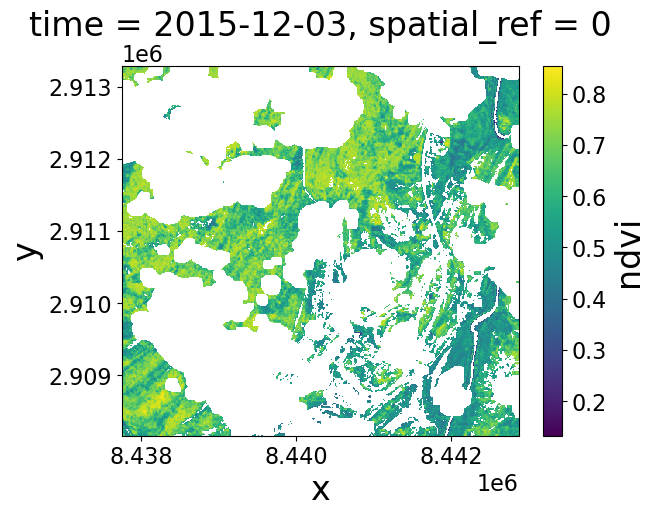

In [22]:
print(f"🔄 Processing minicube FID 0...")

path = f"{s2_minicube_folder}/0_10_512_20152024_equi7_NA.nc"
mc = load_netcdf(path)

if not mc.rio.crs:
    mc = mc.rio.write_crs(equi7_crs)

mc.ndvi.isel(time=20).plot()

In [14]:
if ids_gdf.crs != equi7_crs:
    ids_gdf = ids_gdf.to_crs(equi7_crs)
    print(f"🌍 Transformed IDS to CRS {equi7_crs}.")

ids_shape = gpd.GeoSeries(ids_gdf.geometry)

clipped_ids = mc.rio.clip(ids_shape.geometry.apply(mapping), drop=True)

🌍 Transformed IDS to CRS EPSG:27705.


In [21]:
ids_shape

0       POLYGON ((9586823.354 2905414.907, 9587399.831...
1       POLYGON ((9511144.735 3132918.23, 9511138.057 ...
2       POLYGON ((9625097.53 3111099.634, 9625070.97 3...
3       POLYGON ((9540987.283 3176585.115, 9540981.997...
4       POLYGON ((8943525.3 2462053.1, 8943523.01 2462...
                              ...                        
2223    POLYGON ((8962993.816 2535648.091, 8962959.419...
2224    POLYGON ((8964996.395 2533790.758, 8964962.016...
2225    POLYGON ((8978492.248 2438153.22, 8978459.179 ...
2226    POLYGON ((8949250.555 2533305.896, 8949216.25 ...
2227    POLYGON ((8945314.036 2533185.532, 8945279.749...
Name: geometry, Length: 2228, dtype: geometry

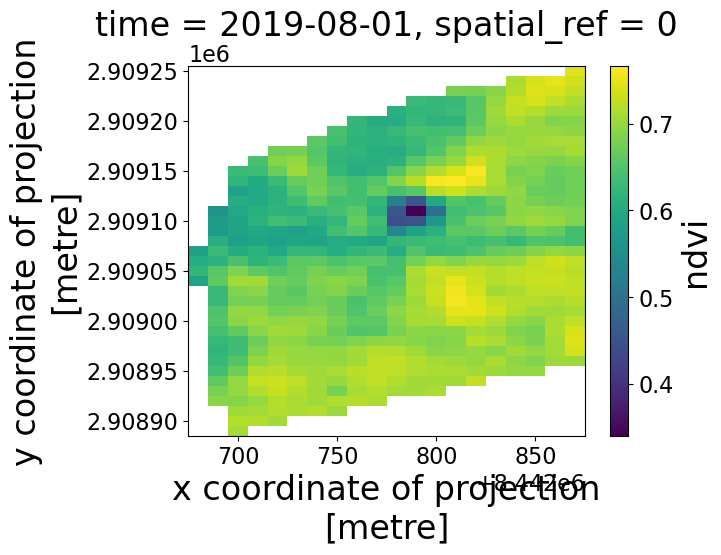

In [23]:
clipped_ids.ndvi.isel(time=200).plot()